In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [19]:
pd.set_option("display.max_columns", None)

In [2]:
import warnings
warnings.filterwarnings("ignore")

#### data processing

In [3]:
data_path = "../data/"
output_path = "../output/"

In [4]:
data = pd.read_csv(data_path + "diabetes_130_full.csv", low_memory = False)

In [5]:
### Assign relevant item mapping to id from csv

IDs_mapping = pd.read_csv(data_path + "IDS_mapping.csv")

admission_id_mapping = IDs_mapping.iloc[:8, :]
admission_id_mapping['admission_type_id'] = admission_id_mapping['admission_type_id'].astype(int)
admission_id_mapping = admission_id_mapping.set_index('admission_type_id')['description'].to_dict()

discharge_id_mapping = IDs_mapping.iloc[10:40, :]
discharge_id_mapping['admission_type_id'] = discharge_id_mapping['admission_type_id'].astype(int)
discharge_id_mapping = discharge_id_mapping.set_index('admission_type_id')['description'].to_dict()

admission_source_id_mapping = IDs_mapping.iloc[42:, :]
admission_source_id_mapping['admission_type_id'] = admission_source_id_mapping['admission_type_id'].astype(int)
admission_source_id_mapping = admission_source_id_mapping.set_index('admission_type_id')['description'].to_dict()

data['admission_type_id'] = data['admission_type_id'].map(admission_id_mapping)
data['discharge_disposition_id'] = data['discharge_disposition_id'].map(discharge_id_mapping)
data['admission_source_id'] = data['admission_source_id'].map(admission_source_id_mapping)

In [6]:
data.drop(columns = ['Unnamed: 0'], axis = 1, inplace = True)

In [7]:
### drop repeated encounters, only keep the first. 

data.sort_values(by = ['encounter_id'], inplace = True)
data = data.drop_duplicates(subset='patient_nbr', keep='first')      

In [8]:
data = data[data['gender'].isin(['Female', 'Male'])]  # drop 3 rows, small missing

In [9]:
data.shape

(71515, 50)

#### start

In [11]:
df = data.copy()

##### drop factors

In [12]:
### drop weight due to 96% missing

df.drop(columns = ['weight'], axis = 1, inplace = True)

In [13]:
### these factors do not have qualitative / inherent meaning

df.drop(columns = ['admission_source_id', 'payer_code', 'medical_specialty','encounter_id', 'patient_nbr'], 
        axis = 1, 
        inplace = True)

In [46]:
mapping = {'NO': 0, '>30': 1, '<30': 1}
df['readmitted_binary'] = df['readmitted'].map(mapping)

### Single Factor Analysis (WoE and IV)

##### Categorical Variables

In [47]:
categorical_var = ['race', 'gender', 'age', 
                   'change', 'diabetesMed', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'metformin',
                   'max_glu_serum', 'A1Cresult',
                   'readmitted_binary'
                  ]

In [111]:
def woe_discrete(categorical_var):
    
    WoE_results = pd.DataFrame()

    WoE_results[categorical_var] = df[categorical_var].copy()
    WoE_results['Bad'] = df['readmitted_binary']

    WoE_results[categorical_var] = WoE_results[categorical_var].fillna('Missing')

    Count = WoE_results.groupby([categorical_var]).count().reset_index()
    Mean = WoE_results.groupby([categorical_var]).mean().reset_index()

    df1 = pd.concat([Count, Mean], axis = 1)
    df1 = df1.iloc[:,[0,1,3]]

    df1.columns = [categorical_var, 'n_obs', 'prop_bad']

    df1['prop_good'] = 1 - df1['prop_bad']

    df1['n_bad'] = df1['prop_bad'] * df1['n_obs']
    df1['n_good'] = df1['prop_good'] * df1['n_obs']

    df1['prop_n_bad'] = df1['n_bad'] / df1['n_bad'].sum()
    df1['prop_n_good'] = df1['n_good'] / df1['n_good'].sum()

    df1['WoE'] = np.log((df1['prop_n_good'] + 1e-10) / (df1['prop_n_bad'] + + 1e-10))

    df1['%Good - %Bad'] = df1['prop_n_good'] - df1['prop_n_bad'] 

    df1['IV'] = df1['WoE'] * df1['%Good - %Bad']

    df1.IV = df1.IV.sum()

    df1['prop_total'] = df1['n_obs'] / df1['n_obs'].sum()
    
    df1.sort_values(by=categorical_var, inplace = True)

    return df1

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()                                #make sns the default style compared to matplotlib

def plot_by_woe(df, rotation_of_x_axis_labels = 0):
    x = np.array(df.iloc[:, 0].apply(str))               #matplotlib works better with numpy and scipy
    y = df['WoE']
    plt.figure(figsize=(18, 6))
    plt.plot(x, y, marker = 'o', linestyle = '--', color = 'k')
    plt.xlabel(df.columns[0])
    plt.ylabel('Weight of Evidence')
    plt.title(str('Weight of Evidence by ' + df.columns[0]))
    plt.xticks(rotation = rotation_of_x_axis_labels)

#looks ok

In [130]:
iv_dict = {}

for var in categorical_var:
    result_df = woe_discrete(var)
    iv_value = result_df['IV'].iloc[0] 
    iv_dict[var] = iv_value

iv_dict = dict(sorted(iv_dict.items(), key=lambda x: x[1], reverse=True))

for k, v in iv_dict.items():
    print(f"{k}: {v:.4f}")

readmitted_binary: 46.0517
age: 0.0265
diabetesMed: 0.0173
race: 0.0109
insulin: 0.0076
change: 0.0064
glipizide: 0.0039
rosiglitazone: 0.0027
A1Cresult: 0.0019
pioglitazone: 0.0017
max_glu_serum: 0.0016
metformin: 0.0013
gender: 0.0012
glyburide: 0.0007
glimepiride: 0.0002


In [144]:
woe_discrete('age')

,age,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,[0-10),154,0.175325,0.824675,27.0,127.0,0.000946,0.002955,1.138630,0.002008,0.026521,0.002153
1,[10-20),535,0.314019,0.685981,168.0,367.0,0.005888,0.008538,0.371678,0.002651,0.026521,0.007481
2,[20-30),1127,0.319432,0.680568,360.0,767.0,0.012617,0.017845,0.346663,0.005228,0.026521,0.015759
3,[30-40),2699,0.324935,0.675065,877.0,1822.0,0.030736,0.042390,0.321463,0.011653,0.026521,0.037740
4,[40-50),6878,0.356499,0.643501,2452.0,4426.0,0.085936,0.102973,0.180872,0.017038,0.026521,0.096176
5,[50-60),12466,0.370047,0.629953,4613.0,7853.0,0.161672,0.182704,0.122297,0.021032,0.026521,0.174313
6,[60-70),15959,0.398897,0.601103,6366.0,9593.0,0.223110,0.223186,0.000342,0.000076,0.026521,0.223156
7,[70-80),18208,0.436951,0.563049,7956.0,10252.0,0.278835,0.238518,-0.156174,-0.040317,0.026521,0.254604
8,[80-90),11589,0.437311,0.562689,5068.0,6521.0,0.177619,0.151715,-0.157639,-0.025904,0.026521,0.162050
9,[90-100),1900,0.340000,0.660000,646.0,1254.0,0.022640,0.029175,0.253574,0.006535,0.026521,0.026568


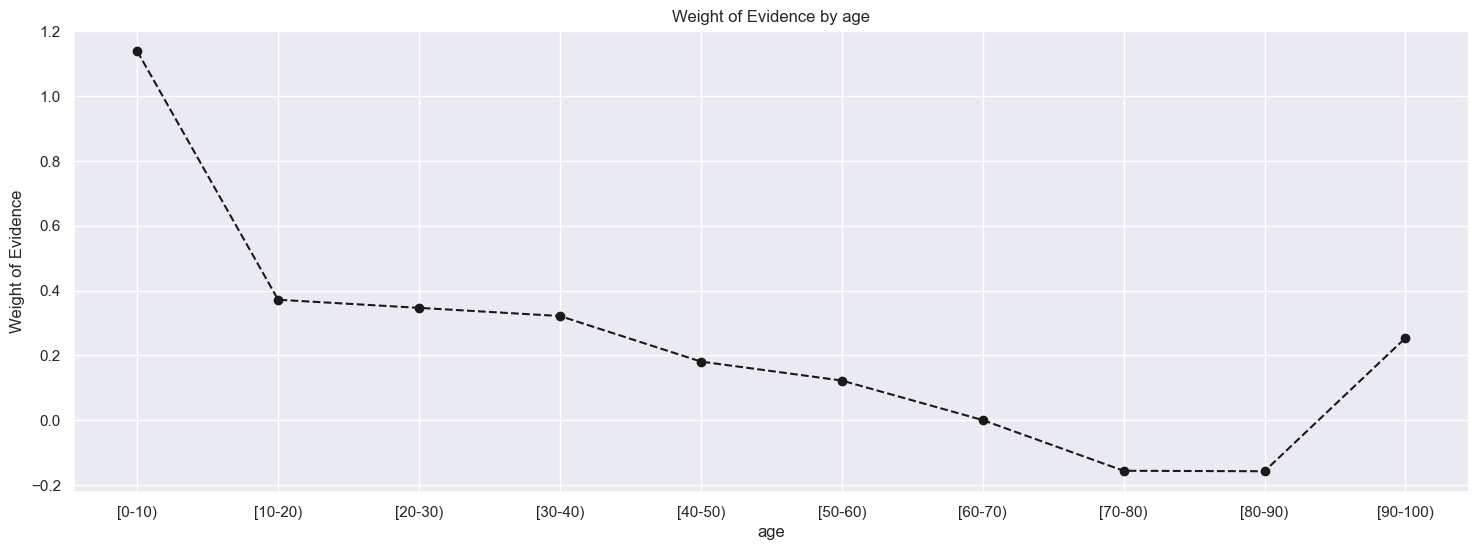

In [138]:
plot_by_woe(woe_discrete('age'))

In [154]:
df['age_coarse'] = df['age'].replace({
    '[0-10)':  '[0-20)',
    '[10-20)': '[0-20)',
    '[20-30)': '[20-40)',
    '[30-40)': '[20-40)',
    '[70-80)': '[70-100)',
    '[80-90)': '[70-100)',
    '[90-100)': '[70-100)'
})

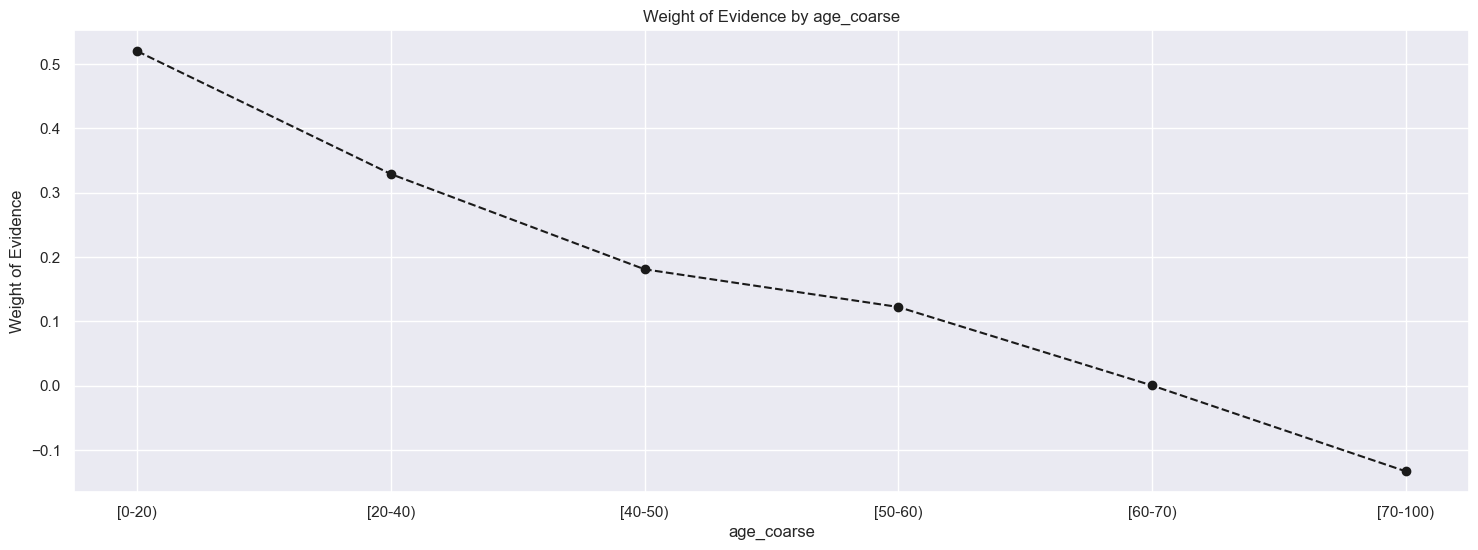

In [155]:
plot_by_woe(woe_discrete('age_coarse'))

In [162]:
woe_discrete('age_coarse')

,age_coarse,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,[0-20),689,0.283019,0.716981,195.0,494.0,0.006834,0.011493,0.519816,0.004659,0.021569,0.009634
1,[20-40),3826,0.323314,0.676686,1237.0,2589.0,0.043353,0.060235,0.328862,0.016881,0.021569,0.053499
2,[40-50),6878,0.356499,0.643501,2452.0,4426.0,0.085936,0.102973,0.180872,0.017038,0.021569,0.096176
3,[50-60),12466,0.370047,0.629953,4613.0,7853.0,0.161672,0.182704,0.122297,0.021032,0.021569,0.174313
4,[60-70),15959,0.398897,0.601103,6366.0,9593.0,0.223110,0.223186,0.000342,0.000076,0.021569,0.223156
5,[70-100),31697,0.431271,0.568729,13670.0,18027.0,0.479094,0.419408,-0.133053,-0.059686,0.021569,0.443222


##### Numerical Variables

In [115]:
numerical_features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient',
                      'number_emergency', 'number_inpatient', 'number_diagnoses']

In [125]:
iv_dict = {}

for var in numerical_features:
    result_df = woe_discrete(var)
    iv_value = result_df['IV'].iloc[0] 
    iv_dict[var] = iv_value

iv_dict = dict(sorted(iv_dict.items(), key=lambda x: x[1], reverse=True))

for k, v in iv_dict.items():
    print(f"{k}: {v:.4f}")

number_inpatient: 0.0947
number_diagnoses: 0.0488
number_emergency: 0.0424
num_medications: 0.0369
number_outpatient: 0.0368
num_lab_procedures: 0.0237
time_in_hospital: 0.0194
num_procedures: 0.0048


In [160]:
woe_discrete('number_inpatient')

,number_inpatient,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,0,63074,0.373926,0.626074,23585.0,39489.0,0.826587,0.918733,0.105691,0.092147,0.094655,0.881969
1,1,5962,0.543274,0.456726,3239.0,2723.0,0.113518,0.063352,-0.583251,-0.050166,0.094655,0.083367
2,2,1547,0.654816,0.345184,1013.0,534.0,0.035503,0.012424,-1.049996,-0.023079,0.094655,0.021632
3,3,489,0.703476,0.296524,344.0,145.0,0.012056,0.003374,-1.273628,-0.008683,0.094655,0.006838
4,4,236,0.758475,0.241525,179.0,57.0,0.006273,0.001326,-1.554055,-0.004947,0.094655,0.003300
5,5,102,0.794118,0.205882,81.0,21.0,0.002839,0.000489,-1.759647,-0.002350,0.094655,0.001426
6,6,56,0.892857,0.107143,50.0,6.0,0.001752,0.000140,-2.529983,-0.001613,0.094655,0.000783
7,7,19,0.894737,0.105263,17.0,2.0,0.000596,0.000047,-2.549784,-0.000549,0.094655,0.000266
8,8,13,0.846154,0.153846,11.0,2.0,0.000386,0.000047,-2.114466,-0.000339,0.094655,0.000182
9,9,8,0.750000,0.250000,6.0,2.0,0.000210,0.000047,-1.508331,-0.000164,0.094655,0.000112


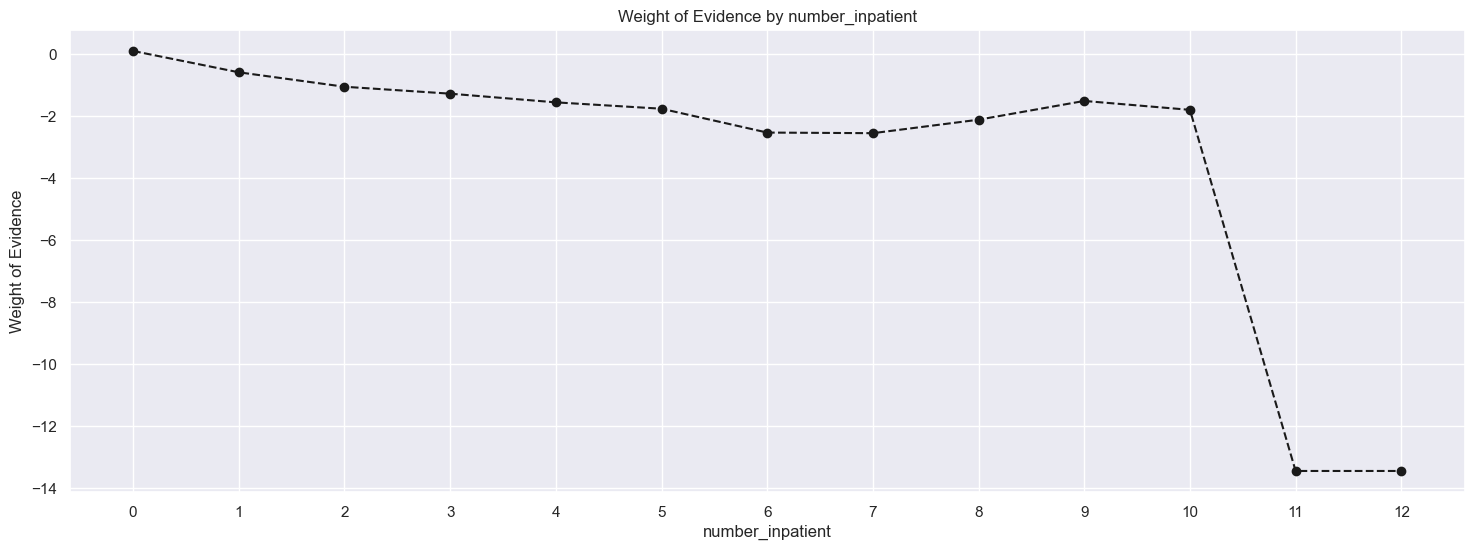

In [158]:
plot_by_woe(woe_discrete('number_inpatient'))

In [161]:
def bin_number_inpatient(x):
    if x == 0:
        return '0'
    elif x == 1:
        return '1'
    elif x == 2:
        return '2'
    elif 3 <= x <= 5:
        return '3-5'
    else:
        return '6+'

df['number_inpatient_coarse'] = df['number_inpatient'].apply(bin_number_inpatient)

In [ ]:
# ordinally encode them
ordinal_features = ['race', 'age']

# keep as they are for numerical
numerical_features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient',
                      'number_emergency', 'number_inpatient', 'number_diagnoses']

# one-hot encode these
one_hot_features = ['gender', 'change', 'diabetesMed']   # pending regroup for 'diag_1', 'diag_2', 'diag_3'

In [ ]:
for col in ordinal_features:
    df[f"{col}_encoded"] = df[col].astype('category').cat.codes     # this will be rank alphabetically, take note!

In [ ]:
df = pd.get_dummies(df, 
                    columns=one_hot_features, 
                    drop_first = True)

#### end

In [ ]:
final_factors = ['time_in_hospital',
                 'num_lab_procedures',
                 'num_procedures', 
                 'num_medications', 
                 'number_outpatient',
                 'number_emergency', 
                 'number_inpatient', 
                 'number_diagnoses',
                 'max_glu_serum_encoded',
                 'A1Cresult_encoded',
                 'metformin_encoded', 
                 'glimepiride_encoded',
                 'glipizide_encoded',
                 'glyburide_encoded',
                 'pioglitazone_encoded',
                 'rosiglitazone_encoded',
                 'insulin_encoded',
                 'race_encoded',
                 'age_encoded',
                 'gender_Male',
                 'change_No',
                 'diabetesMed_Yes']

In [ ]:
mapping = {'NO': 0, '>30': 1, '<30': 1}
df['readmitted_binary'] = df['readmitted'].map(mapping)

In [ ]:
X = df[final_factors]
y = df['readmitted_binary']

In [ ]:
import seaborn as sns

In [ ]:
corr_matrix = X.corr()

plt.figure(figsize=(16,8))
sns.heatmap(corr_matrix, 
            cmap='coolwarm', 
            center=0, 
            annot=True,          
            fmt=".1f",           
            linewidths=0.5)      
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [ ]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [50, 100, 200, 300],        # number of trees
    'max_depth': [None, 5, 10, 20, 30],        # tree depth
    'min_samples_split': [2, 5, 10],        # min samples to split a node
    'min_samples_leaf': [1, 2, 4],          # min samples per leaf
    'max_features': ['sqrt', 'log2']        # feature subset for splitting
}

In [ ]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,                # 3-fold cross-validation
    n_jobs=-1,           # use all CPU cores
    verbose=2,           # show progress
    scoring='roc_auc'         # or 'accuracy', 'roc_auc' depending on your goal
)

In [ ]:
grid_search.fit(X_train, y_train)

In [ ]:
print("Best parameters found:", grid_search.best_params_)
print("Best cross-val score:", grid_search.best_score_)

In [ ]:
best_rf = grid_search.best_estimator_

In [ ]:
y_pred = best_rf.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Probabilities for the positive class
y_pred_proba = best_rf.predict_proba(X_train)[:, 1]

# Compute AUC
auc_score = roc_auc_score(y_train, y_pred_proba)
print("Train AUC-ROC:", auc_score)

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Probabilities for the positive class
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]

# Compute AUC
auc_score = roc_auc_score(y_test, y_pred_proba)
print("Test AUC-ROC:", auc_score)

In [ ]:
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [ ]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns)         # not so good because based on gini impurtiy
print(importances.sort_values(ascending=False).head(15))

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import roc_auc_score

result = permutation_importance(
    best_rf,
    X_test,
    y_test,
    scoring='roc_auc',
    n_repeats=10,
    n_jobs=-1,
    random_state=42
)

importances_auc = pd.Series(result.importances_mean, index=X.columns)
print(importances_auc.sort_values(ascending=False).head(15))